In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
patients = pd.read_csv("cleaned_patients.csv")
encounters = pd.read_csv("cleaned_encounters.csv")
procedures = pd.read_csv("cleaned_procedures.csv")
payers = pd.read_csv("cleaned_payers.csv")
organizations = pd.read_csv("cleaned_organizations.csv")
encounters_sorted = pd.read_csv("cleaned_encounters_with_readmission.csv")
procedures_with_coverage = pd.read_csv("cleaned_procedures_with_coverage.csv")

In [4]:
patients["BIRTHDATE"] = pd.to_datetime(patients["BIRTHDATE"], errors="coerce")
patients["DEATHDATE"] = pd.to_datetime(patients["DEATHDATE"], errors="coerce")

encounters["START"] = pd.to_datetime(encounters["START"], errors="coerce")
encounters["STOP"] = pd.to_datetime(encounters["STOP"], errors="coerce")

procedures["START"] = pd.to_datetime(procedures["START"], errors="coerce")
procedures["STOP"] = pd.to_datetime(procedures["STOP"], errors="coerce")

encounters_sorted["START"] = pd.to_datetime(encounters_sorted["START"], errors="coerce")
encounters_sorted["STOP"] = pd.to_datetime(encounters_sorted["STOP"], errors="coerce")
encounters_sorted["previous_encounter_date"] = pd.to_datetime(
    encounters_sorted["previous_encounter_date"],
    errors="coerce"
)

procedures_with_coverage["START"] = pd.to_datetime(procedures_with_coverage["START"], errors="coerce")
procedures_with_coverage["STOP"] = pd.to_datetime(procedures_with_coverage["STOP"], errors="coerce")

In [6]:
encounters_sorted.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,...,length_of_stay_days,encounter_year,encounter_month,encounter_month_name,encounter_year_month,is_covered_by_insurance,previous_encounter_date,days_since_previous_visit,is_readmission,is_30_day_readmission
0,9365aa07-4ade-2cc0-f90c-a79085396a19,2011-12-22 19:30:33+00:00,2011-12-22 20:30:33+00:00,002bc307-2fff-04ba-161b-98cce123e226,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,emergency,50849002,Emergency Room Admission,146.18,...,0.041667,2011,12,December,2011-12,Covered,NaT,NaN,First Admission,No
1,8fe2eb89-6036-de1e-7a4d-5fb1a663a5f3,2012-01-19 19:30:33+00:00,2012-01-20 19:30:33+00:00,002bc307-2fff-04ba-161b-98cce123e226,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,inpatient,56876005,Drug rehabilitation and detoxification,146.18,...,1.000000,2012,1,January,2012-01,Covered,2011-12-22 19:30:33+00:00,28.0,Readmission,Yes
2,6b263c0d-9804-a271-397c-8e3db7ca0ad1,2014-06-19 19:30:33+00:00,2014-06-20 19:30:33+00:00,002bc307-2fff-04ba-161b-98cce123e226,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,inpatient,56876005,Drug rehabilitation and detoxification,146.18,...,1.000000,2014,6,June,2014-06,Covered,2012-01-19 19:30:33+00:00,882.0,Readmission,No
3,10dab125-bdb0-12db-4c37-fa5e582670a1,2014-10-30 19:30:33+00:00,2014-10-30 19:45:33+00:00,002bc307-2fff-04ba-161b-98cce123e226,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185347001,Encounter for problem (procedure),85.55,...,0.010417,2014,10,October,2014-10,Covered,2014-06-19 19:30:33+00:00,133.0,Readmission,No
4,03da09b8-1228-dd93-5e42-fd71f7e5183c,2014-11-29 19:30:33+00:00,2014-11-29 19:45:33+00:00,002bc307-2fff-04ba-161b-98cce123e226,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185347001,Encounter for problem (procedure),85.55,...,0.010417,2014,11,November,2014-11,Covered,2014-10-30 19:30:33+00:00,30.0,Readmission,Yes


# Business Question 1
# How many patients have been admitted or readmitted over time?

In [7]:
admission_trend = encounters_sorted.groupby("encounter_year_month").agg(
    total_encounters=("Id", "count"),
    unique_patients=("PATIENT", "nunique"),
    readmissions=("is_readmission", lambda x: (x == "Readmission").sum()),
    thirty_day_readmissions=("is_30_day_readmission", lambda x: (x == "Yes").sum())
).reset_index()

admission_trend["readmission_rate"] = (
    admission_trend["readmissions"] / admission_trend["total_encounters"] * 100
)

admission_trend["thirty_day_readmission_rate"] = (
    admission_trend["thirty_day_readmissions"] / admission_trend["total_encounters"] * 100
)

admission_trend.head()

,encounter_year_month,total_encounters,unique_patients,readmissions,thirty_day_readmissions,readmission_rate,thirty_day_readmission_rate
0,2011-01,86,68,18,15,20.930233,17.441860
1,2011-02,86,67,44,32,51.162791,37.209302
2,2011-03,129,85,83,64,64.341085,49.612403
3,2011-04,113,72,74,55,65.486726,48.672566
4,2011-05,131,78,97,70,74.045802,53.435115


### Insight

The monthly admission trend shows that hospital utilization increased from the beginning of 2011. In January 2011, the hospital recorded 86 encounters from 68 unique patients. By May 2011, encounters increased to 131.

Repeat visits form a significant portion of total encounters. This indicates that hospital workload is influenced not only by new patient inflow but also by recurring patient visits.

For this project, 30-day repeat encounters are used as a proxy for readmission behaviour. Since the dataset includes inpatient, outpatient, ambulatory, emergency, urgent care, and wellness visits, this should be interpreted as a repeat-visit indicator rather than a strict clinical readmission rate.

In [8]:
#Latest Months
admission_trend.tail()

,encounter_year_month,total_encounters,unique_patients,readmissions,thirty_day_readmissions,readmission_rate,thirty_day_readmission_rate
129,2021-10,225,119,223,143,99.111111,63.555556
130,2021-11,267,134,266,174,99.625468,65.168539
131,2021-12,231,110,231,171,100.000000,74.025974
132,2022-01,219,103,219,147,100.000000,67.123288
133,2022-02,1,1,1,1,100.000000,100.000000


In [9]:
#Top 10 Business Months
top_10_busy_months = admission_trend.sort_values(
    "total_encounters", 
    ascending=False
).head(10)

top_10_busy_months

,encounter_year_month,total_encounters,unique_patients,readmissions,thirty_day_readmissions,readmission_rate,thirty_day_readmission_rate
37,2014-02,1179,269,1151,971,97.625106,82.357930
38,2014-03,456,266,447,318,98.026316,69.736842
122,2021-03,452,297,449,255,99.336283,56.415929
123,2021-04,421,284,416,280,98.812352,66.508314
124,2021-05,342,206,339,239,99.122807,69.883041
121,2021-02,328,226,325,183,99.085366,55.792683
130,2021-11,267,134,266,174,99.625468,65.168539
119,2020-12,267,139,266,177,99.625468,66.292135
120,2021-01,263,166,263,130,100.000000,49.429658
126,2021-07,263,154,260,153,98.859316,58.174905


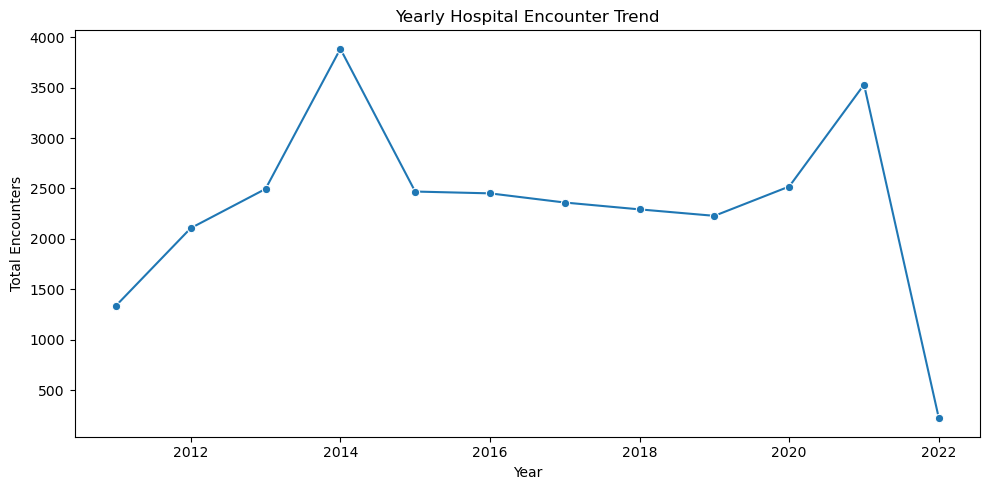

In [10]:
#Visualization
admission_trend_yearly = encounters_sorted.groupby("encounter_year").agg(
    total_encounters=("Id", "count"),
    unique_patients=("PATIENT", "nunique"),
    readmissions=("is_readmission", lambda x: (x == "Readmission").sum()),
    thirty_day_readmissions=("is_30_day_readmission", lambda x: (x == "Yes").sum())
).reset_index()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=admission_trend_yearly,
    x="encounter_year",
    y="total_encounters",
    marker="o"
)

plt.title("Yearly Hospital Encounter Trend")
plt.xlabel("Year")
plt.ylabel("Total Encounters")
plt.tight_layout()
plt.show()

### Business Question 1: How many patients have been admitted or readmitted over time?

The analysis shows that hospital encounters increased from 2011 and reached a major peak in 2014. February 2014 was the busiest month, with 1,179 total encounters and 269 unique patients.

The data also shows that repeat visits form a large part of the hospital workload. This suggests that operational planning should not focus only on new patients, but also on returning patients who continue to use hospital services.

A second rise is visible in 2021, indicating another high-utilization period for the hospital.

However, the sharp decline in 2022 should not be interpreted as a real fall in demand because the dataset ends in February 2022. Hence, 2022 is an incomplete year.

For this project, 30-day repeat encounters are used as a proxy for readmission behaviour. Since the dataset includes outpatient, ambulatory, wellness, emergency, urgent care, and inpatient encounters, this metric should be interpreted as a repeat-visit indicator rather than a strict clinical readmission rate.

# Business Question 2
What is the average length of hospital stay?

In [11]:
# Overall Average Length of Stay

avg_los_hours = encounters["length_of_stay_hours"].mean()
avg_los_days = encounters["length_of_stay_days"].mean()

print("Average Length of Stay in Hours:", round(avg_los_hours, 2))
print("Average Length of Stay in Days:", round(avg_los_days, 2))

Average Length of Stay in Hours: 7.27
Average Length of Stay in Days: 0.3


In [12]:
# Length of Stay Summary
encounters[["length_of_stay_hours", "length_of_stay_days"]].describe()

,length_of_stay_hours,length_of_stay_days
count,27891.000000,27891.000000
mean,7.265995,0.302750
std,398.323624,16.596818
min,0.250000,0.010417
25%,0.250000,0.010417
50%,0.250000,0.010417
75%,0.864167,0.036007
max,44930.000000,1872.083333


In [13]:
#Average staay by Encounter Class
los_by_encounter_class = encounters.groupby("ENCOUNTERCLASS").agg(
    total_encounters=("Id", "count"),
    avg_los_hours=("length_of_stay_hours", "mean"),
    median_los_hours=("length_of_stay_hours", "median"),
    avg_los_days=("length_of_stay_days", "mean"),
    median_los_days=("length_of_stay_days", "median")
).reset_index()

los_by_encounter_class = los_by_encounter_class.sort_values(
    "avg_los_hours", 
    ascending=False
)

los_by_encounter_class

,ENCOUNTERCLASS,total_encounters,avg_los_hours,median_los_hours,avg_los_days,median_los_days
2,inpatient,1135,36.841586,24.00,1.535066,1.000000
0,ambulatory,12537,9.479418,0.25,0.394976,0.010417
3,outpatient,6300,5.875872,0.25,0.244828,0.010417
1,emergency,2322,1.541755,1.00,0.064240,0.041667
4,urgentcare,3666,0.250000,0.25,0.010417,0.010417
5,wellness,1931,0.250000,0.25,0.010417,0.010417


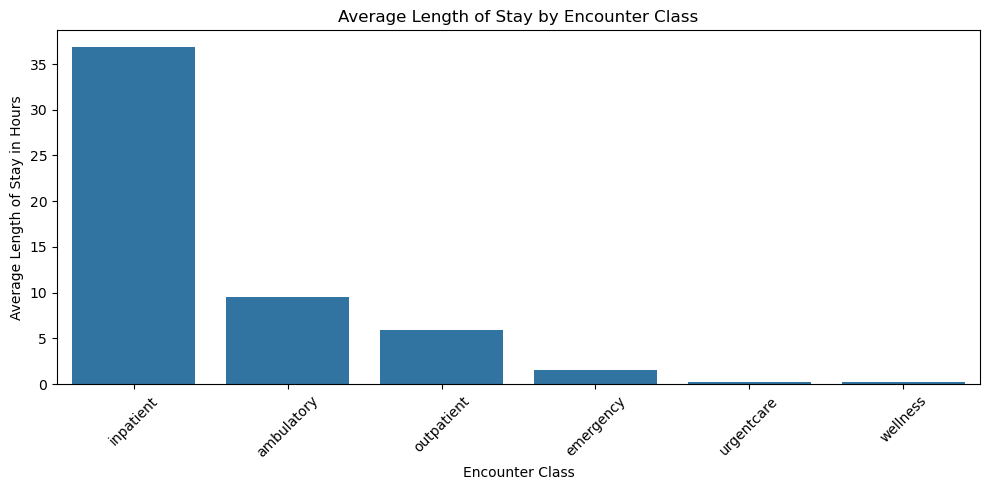

In [15]:
#Visualization
plt.figure(figsize=(10, 5))

sns.barplot(
    data=los_by_encounter_class,
    x="ENCOUNTERCLASS",
    y="avg_los_hours"
)

plt.title("Average Length of Stay by Encounter Class")
plt.xlabel("Encounter Class")
plt.ylabel("Average Length of Stay in Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Question 2: What is the average length of hospital stay?

The overall average length of stay is 7.27 hours, which is approximately 0.30 days. However, the median length of stay is only 0.25 hours, showing that most encounters are short-duration visits.

The difference between the mean and median suggests the presence of outliers. The maximum recorded length of stay is 44,930 hours, or around 1,872 days, which significantly increases the average.

By encounter class, inpatient visits have the highest average length of stay at 36.84 hours, with a median of 24 hours. This is expected because inpatient care usually involves admission and longer monitoring. Ambulatory and outpatient visits show lower median stays, while urgent care and wellness encounters are mostly short visits.

For hospital operations, this means inpatient encounters, even though smaller in count, create higher bed occupancy pressure compared to outpatient or wellness encounters.

In [17]:
long_stays = encounters.sort_values(
    "length_of_stay_days",
    ascending=False
)[[
    "Id",
    "PATIENT",
    "START",
    "STOP",
    "ENCOUNTERCLASS",
    "DESCRIPTION",
    "length_of_stay_hours",
    "length_of_stay_days",
    "TOTAL_CLAIM_COST"
]].head(10)

long_stays

,Id,PATIENT,START,STOP,ENCOUNTERCLASS,DESCRIPTION,length_of_stay_hours,length_of_stay_days,TOTAL_CLAIM_COST
9704,fc2c2add-0b55-e300-5cea-8f43044eb330,5d47b9ac-3f37-f400-1747-c6c6f92130aa,2014-12-17 11:49:08+00:00,2020-02-01 13:49:08+00:00,ambulatory,Follow-up encounter (procedure),44930.000000,1872.083333,85.55
7735,2cb41a50-819c-ef7e-87df-b5b47b2e01a1,09e0ec41-cd4c-50b2-b425-824013777beb,2014-03-27 00:33:14+00:00,2019-03-13 15:33:14+00:00,ambulatory,Follow-up encounter (procedure),43503.000000,1812.625000,85.55
7805,7a19a260-e4a9-7b81-3f93-e07144d634d9,8885aba5-afce-9e3b-0c1d-a684a347b5fb,2014-04-02 22:26:28+00:00,2015-07-02 13:44:57+00:00,ambulatory,Follow-up encounter (procedure),10935.308056,455.637836,85.55
6116,3cf29374-f91a-5877-9356-87792501d225,a12541db-140e-8189-070c-dc9f4815f40f,2014-01-31 02:29:54+00:00,2015-04-22 02:29:54+00:00,outpatient,Encounter for problem (procedure),10704.000000,446.000000,85.55
6371,63b7c71f-23f5-32dc-b63a-cca7bf5625a2,6e8e0498-187a-d038-c7af-716b12e70455,2014-02-06 02:17:34+00:00,2015-01-20 02:17:34+00:00,outpatient,Encounter for problem (procedure),8352.000000,348.000000,85.55
18343,4079872d-73da-3b52-5306-2a978c6f5c8c,54889029-0a1e-0b75-5980-1c091dd4bc0e,2018-07-18 23:56:20+00:00,2019-06-27 17:56:35+00:00,inpatient,Periodic reevaluation and management of health...,8250.004167,343.750174,7093.85
6380,110777dd-6aca-3c9c-7119-ab2494c0665e,0ec939a0-559c-7bc9-db9c-a7feae58634a,2014-02-06 04:57:58+00:00,2015-01-13 04:57:58+00:00,outpatient,Encounter for problem (procedure),8184.000000,341.000000,85.55
7832,04df7388-7a70-3e99-c0fe-7f7ddd062931,ea9d6669-efc3-3c16-4f70-70cc1c1659d7,2014-04-04 22:41:46+00:00,2015-01-31 13:54:32+00:00,ambulatory,Follow-up encounter (procedure),7239.212778,301.633866,85.55
6125,d0476a31-1524-f23f-fb79-290ecd6206aa,f6932663-d920-6e76-89e1-21a6b43cf03b,2014-01-31 11:10:57+00:00,2014-06-25 11:10:57+00:00,outpatient,Encounter for problem (procedure),3480.000000,145.000000,85.55
6332,dcc730d3-4d74-5e75-ae03-cd23c0ee742c,60d2d35e-bd32-36df-b8e0-b64a3494f0e8,2014-02-05 08:41:28+00:00,2014-04-14 08:41:28+00:00,outpatient,Encounter for problem (procedure),1632.000000,68.000000,85.55


### Outlier Note

A few encounters have unusually long durations. These records were retained because this is a synthetic healthcare dataset and the long stays may represent extended care episodes. For dashboarding, both mean and median length of stay should be shown to avoid misleading interpretation.

## Business Question 3
What is the average cost per visit?

In [18]:
#Patient Out-of-Pocket Cost
encounters["patient_out_of_pocket_cost"] = (
    encounters["TOTAL_CLAIM_COST"] - encounters["PAYER_COVERAGE"]
)

In [19]:
#Checking if there are any negative values
encounters[encounters["patient_out_of_pocket_cost"] < 0][[
    "Id",
    "TOTAL_CLAIM_COST",
    "PAYER_COVERAGE",
    "patient_out_of_pocket_cost"
]].head()

,Id,TOTAL_CLAIM_COST,PAYER_COVERAGE,patient_out_of_pocket_cost


In [20]:
#Overall Average Cost Per Visit
avg_base_cost = encounters["BASE_ENCOUNTER_COST"].mean()
avg_claim_cost = encounters["TOTAL_CLAIM_COST"].mean()
avg_payer_coverage = encounters["PAYER_COVERAGE"].mean()
avg_patient_cost = encounters["patient_out_of_pocket_cost"].mean()

print("Average Base Encounter Cost:", round(avg_base_cost, 2))
print("Average Total Claim Cost:", round(avg_claim_cost, 2))
print("Average Payer Coverage:", round(avg_payer_coverage, 2))
print("Average Patient Out-of-Pocket Cost:", round(avg_patient_cost, 2))

Average Base Encounter Cost: 116.18
Average Total Claim Cost: 3639.68
Average Payer Coverage: 1114.97
Average Patient Out-of-Pocket Cost: 2524.72


In [21]:
#Cost Summary
encounters[[
    "BASE_ENCOUNTER_COST",
    "TOTAL_CLAIM_COST",
    "PAYER_COVERAGE",
    "patient_out_of_pocket_cost"
]].describe()

,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,patient_out_of_pocket_cost
count,27891.000000,27891.000000,27891.000000,27891.000000
mean,116.181614,3639.682174,1114.965652,2524.716523
std,28.410082,9205.595748,4768.615576,7661.005002
min,85.550000,0.000000,0.000000,0.000000
25%,85.550000,142.580000,0.000000,85.550000
50%,136.800000,278.580000,28.440000,172.590000
75%,142.580000,1412.530000,155.770000,1004.630000
max,146.180000,641882.700000,247751.420000,641882.700000


In [22]:
#Average cost by Encounter Class
cost_by_encounter_class = encounters.groupby("ENCOUNTERCLASS").agg(
    total_encounters=("Id", "count"),
    avg_base_cost=("BASE_ENCOUNTER_COST", "mean"),
    avg_claim_cost=("TOTAL_CLAIM_COST", "mean"),
    avg_payer_coverage=("PAYER_COVERAGE", "mean"),
    avg_patient_cost=("patient_out_of_pocket_cost", "mean"),
    total_claim_cost=("TOTAL_CLAIM_COST", "sum"),
    total_payer_coverage=("PAYER_COVERAGE", "sum"),
    total_patient_cost=("patient_out_of_pocket_cost", "sum")
).reset_index()

cost_by_encounter_class = cost_by_encounter_class.sort_values(
    "avg_claim_cost",
    ascending=False
)

cost_by_encounter_class

,ENCOUNTERCLASS,total_encounters,avg_base_cost,avg_claim_cost,avg_payer_coverage,avg_patient_cost,total_claim_cost,total_payer_coverage,total_patient_cost
2,inpatient,1135,113.673771,7761.351841,3250.013172,4511.338670,8809134.34,3688764.95,5120369.39
4,urgentcare,3666,142.580000,6369.162564,834.399817,5534.762747,23349349.96,3058909.73,20290440.23
1,emergency,2322,145.248307,4629.651822,1398.289522,3231.362300,10750051.53,3246828.27,7503223.26
5,wellness,1931,136.800000,4260.710373,2289.875681,1970.834692,8227431.73,4421749.94,3805681.79
0,ambulatory,12537,105.729076,2894.108705,1029.233130,1864.875575,36283440.84,12903495.75,23379945.09
3,outpatient,6300,105.039776,2237.296368,599.644183,1637.652186,14094967.12,3777758.35,10317208.77


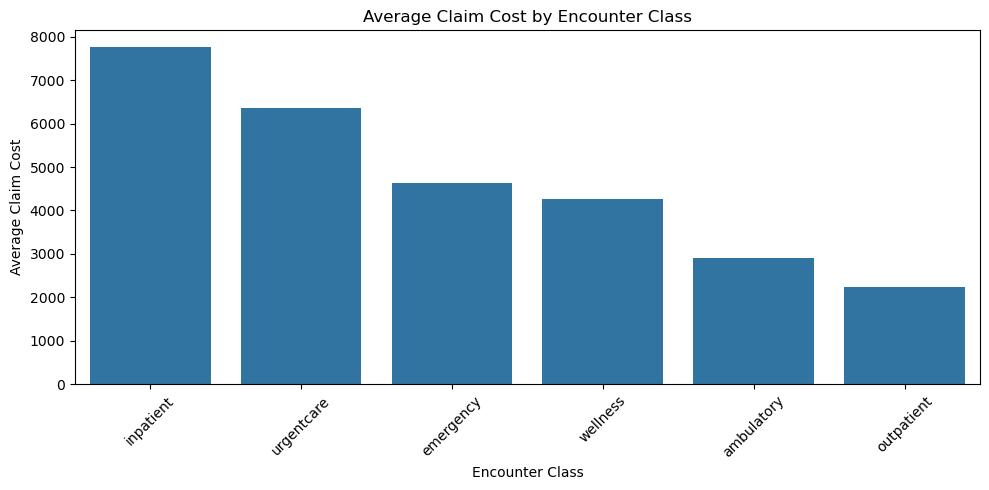

In [23]:
#Visualization : Average claim cost by encounter class
plt.figure(figsize=(10, 5))

sns.barplot(
    data=cost_by_encounter_class,
    x="ENCOUNTERCLASS",
    y="avg_claim_cost"
)

plt.title("Average Claim Cost by Encounter Class")
plt.xlabel("Encounter Class")
plt.ylabel("Average Claim Cost")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

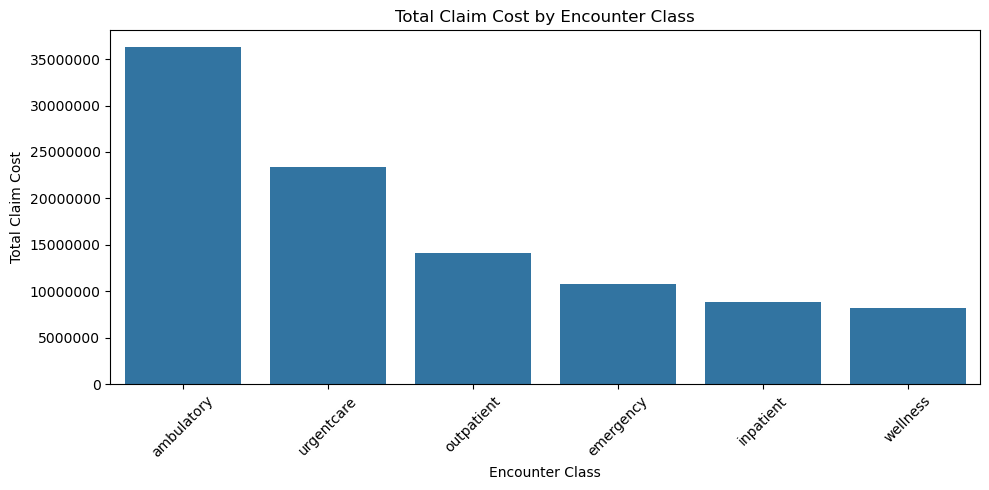

In [26]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=cost_by_encounter_class.sort_values("total_claim_cost", ascending=False),
    x="ENCOUNTERCLASS",
    y="total_claim_cost"
)

plt.title("Total Claim Cost by Encounter Class")
plt.xlabel("Encounter Class")
plt.ylabel("Total Claim Cost")

plt.ticklabel_format(style="plain", axis="y")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Inpatient encounters are the most expensive per visit, while ambulatory encounters create the highest total financial impact due to high visit volume

# Business Question 3: What is the average cost per visit?

The average total claim cost per visit is 3,639.68. On average, insurance or payer coverage contributes 1,114.97, while the average patient out-of-pocket cost is 2,524.72.

However, the median total claim cost is only 278.58, which shows that most encounters are relatively low or moderate in cost. The average is much higher because a few very expensive encounters pull the mean upward.

By encounter class, inpatient encounters have the highest average claim cost at 7,761.35, followed by urgent care and emergency encounters. This indicates that inpatient care is the most expensive on a per-visit basis.

However, when total claim cost is analyzed, ambulatory encounters contribute the highest overall financial impact because they have the highest encounter volume. This distinction is important: inpatient encounters are cost-intensive, while ambulatory encounters are volume-intensive.

For hospital management, this means financial planning should separately monitor high-cost encounter types and high-volume encounter types.

# Business Question 4
How many procedures are covered by insurance?

In [27]:
# Check Procedure Coverage Count

procedure_coverage_count = procedures_with_coverage["is_covered_by_insurance"].value_counts()

procedure_coverage_count


is_covered_by_insurance
Covered        24791
Not Covered    22910
Name: count, dtype: int64

In [28]:
#Check procedure coverage percentage
procedure_coverage_percentage = (
    procedures_with_coverage["is_covered_by_insurance"]
    .value_counts(normalize=True) * 100
).round(2)

procedure_coverage_percentage

is_covered_by_insurance
Covered        51.97
Not Covered    48.03
Name: proportion, dtype: float64

In [29]:
#Coverage summary table
procedure_coverage_summary = procedures_with_coverage.groupby("is_covered_by_insurance").agg(
    total_procedures=("DESCRIPTION", "count"),
    unique_patients=("PATIENT", "nunique"),
    unique_encounters=("ENCOUNTER", "nunique"),
    total_procedure_base_cost=("BASE_COST", "sum"),
    avg_procedure_base_cost=("BASE_COST", "mean")
).reset_index()

procedure_coverage_summary

,is_covered_by_insurance,total_procedures,unique_patients,unique_encounters,total_procedure_base_cost,avg_procedure_base_cost
0,Covered,24791,589,6572,40732049,1643.017587
1,Not Covered,22910,454,8098,64785662,2827.833348


In [30]:
#Coverage by procedure
coverage_by_procedure = procedures_with_coverage.groupby(
    ["DESCRIPTION", "is_covered_by_insurance"]
).agg(
    total_procedures=("DESCRIPTION", "count"),
    unique_patients=("PATIENT", "nunique"),
    total_base_cost=("BASE_COST", "sum"),
    avg_base_cost=("BASE_COST", "mean")
).reset_index()

coverage_by_procedure.sort_values(
    "total_procedures",
    ascending=False
).head(20)

,DESCRIPTION,is_covered_by_insurance,total_procedures,unique_patients,total_base_cost,avg_base_cost
127,Hospice care (regime/therapy),Covered,2717,46,1171027,431.000000
17,Assessment of health and social care needs (pr...,Covered,2538,327,1093878,431.000000
18,Assessment of health and social care needs (pr...,Not Covered,2058,285,886998,431.000000
85,Depression screening using Patient Health Ques...,Covered,2020,321,870620,431.000000
81,Depression screening (procedure),Covered,2020,321,870620,431.000000
229,Renal dialysis (procedure),Not Covered,1880,2,1878158,999.020213
23,Assessment using Morse Fall Scale (procedure),Covered,1690,237,728390,431.000000
82,Depression screening (procedure),Not Covered,1594,274,687014,431.000000
86,Depression screening using Patient Health Ques...,Not Covered,1594,274,687014,431.000000
19,Assessment of substance use (procedure),Covered,1575,276,678825,431.000000


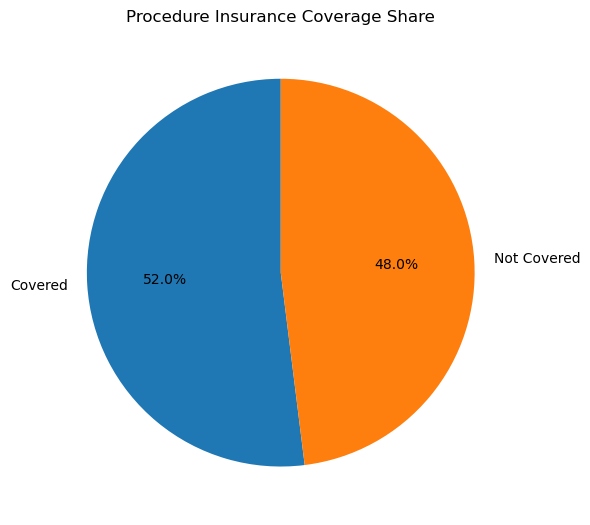

In [31]:
# Visualization
plt.figure(figsize=(6, 6))

plt.pie(
    procedure_coverage_count.values,
    labels=procedure_coverage_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Procedure Insurance Coverage Share")
plt.tight_layout()
plt.show()

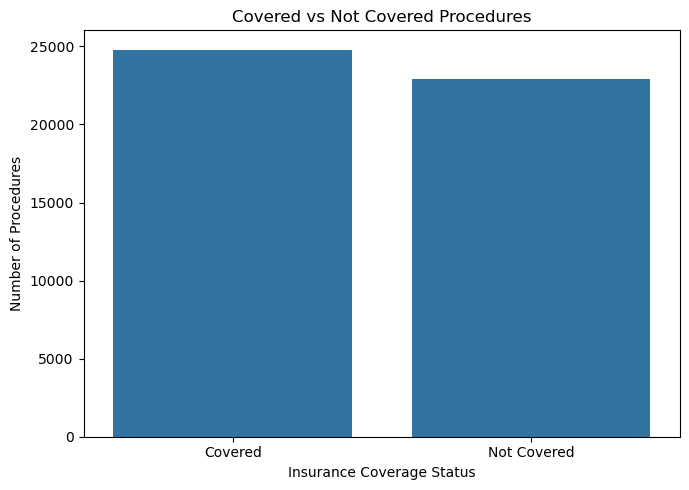

In [32]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=procedure_coverage_count.index,
    y=procedure_coverage_count.values
)

plt.title("Covered vs Not Covered Procedures")
plt.xlabel("Insurance Coverage Status")
plt.ylabel("Number of Procedures")
plt.tight_layout()
plt.show()

# Business Question 4: How many procedures are covered by insurance?

Out of 47,701 recorded procedures, 24,791 procedures are covered by insurance, while 22,910 procedures are not covered. This means 51.97% of procedures are covered and 48.03% are not covered.

Although covered procedures are slightly higher in count, uncovered procedures have a much larger financial impact. Covered procedures account for a total base cost of 40.73 million, while not-covered procedures account for 64.79 million.

The average base cost of covered procedures is 1,643.02, whereas the average base cost of not-covered procedures is 2,827.83. This suggests that patients may face greater financial burden when procedures are not covered by insurance.

Procedure-level analysis shows that hospice care, health and social care assessment, depression screening, renal dialysis, medication reconciliation, and electrical cardioversion are among the important procedures in terms of volume or cost.

For hospital finance and insurance teams, this insight is important because uncovered high-cost procedures can increase patient financial risk and may also affect billing recovery and affordability.

# Business Question 5
Which age group has the highest hospital admissions?

In [33]:
"encounters_patient" in globals()

False

In [34]:
encounters_patient = encounters.merge(
    patients[["Id", "BIRTHDATE", "GENDER", "RACE", "ETHNICITY", "MARITAL"]],
    left_on="PATIENT",
    right_on="Id",
    how="left",
    suffixes=("", "_patient")
)

In [35]:
# Creating age at encounter
encounters_patient["age_at_encounter"] = (
    encounters_patient["START"].dt.year - encounters_patient["BIRTHDATE"].dt.year
)

In [36]:
#Age Group
def age_group(age):
    if pd.isna(age):
        return "Unknown"
    elif age <= 18:
        return "0-18"
    elif age <= 35:
        return "19-35"
    elif age <= 50:
        return "36-50"
    elif age <= 65:
        return "51-65"
    else:
        return "65+"

encounters_patient["age_group"] = encounters_patient["age_at_encounter"].apply(age_group)

In [37]:
encounters_patient[[
    "PATIENT",
    "START",
    "BIRTHDATE",
    "age_at_encounter",
    "age_group",
    "GENDER",
    "RACE",
    "ETHNICITY"
]].head()

,PATIENT,START,BIRTHDATE,age_at_encounter,age_group,GENDER,RACE,ETHNICITY
0,3de74169-7f67-9304-91d4-757e0f3a14d2,2011-01-02 09:26:36+00:00,1928-08-25,83,65+,M,white,nonhispanic
1,d9ec2e44-32e9-9148-179a-1653348cc4e2,2011-01-03 05:44:39+00:00,1964-01-05,47,36-50,F,white,nonhispanic
2,73babadf-5b2b-fee7-189e-6f41ff213e01,2011-01-03 14:32:11+00:00,1924-06-30,87,65+,F,asian,nonhispanic
3,3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b,2011-01-03 16:24:45+00:00,1923-05-21,88,65+,M,white,nonhispanic
4,fa006887-d93c-d302-8b89-f3c25f88c0e1,2011-01-03 17:36:53+00:00,1952-11-02,59,51-65,M,white,nonhispanic


In [38]:
# Admissions by Age Group
admissions_by_age_group = encounters_patient.groupby("age_group").agg(
    total_encounters=("Id", "count"),
    unique_patients=("PATIENT", "nunique"),
    avg_claim_cost=("TOTAL_CLAIM_COST", "mean"),
    total_claim_cost=("TOTAL_CLAIM_COST", "sum"),
    avg_length_of_stay_hours=("length_of_stay_hours", "mean")
).reset_index()

admissions_by_age_group = admissions_by_age_group.sort_values(
    "total_encounters",
    ascending=False
)

admissions_by_age_group

,age_group,total_encounters,unique_patients,avg_claim_cost,total_claim_cost,avg_length_of_stay_hours
3,65+,18626,548,3345.076108,62305387.58,3.003078
2,51-65,3616,268,2478.662848,8962844.86,5.481098
1,36-50,3208,263,4013.013522,12873747.38,8.742388
0,19-35,2441,141,7116.917534,17372395.70,40.497866


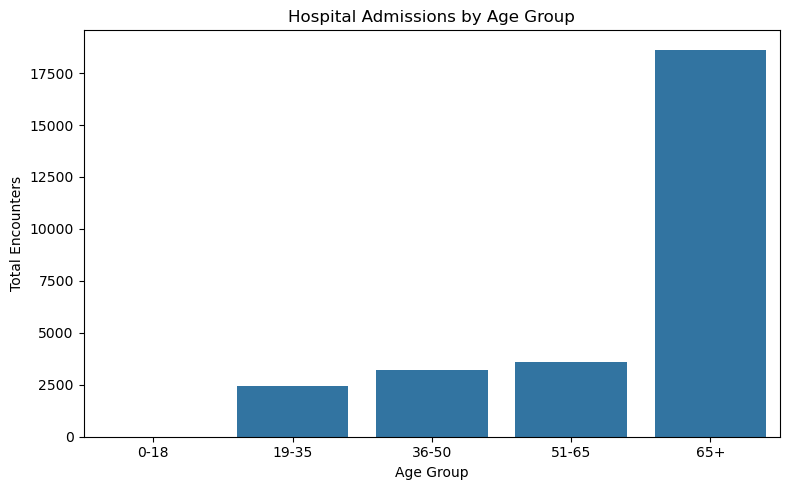

In [41]:
age_order = ["0-18", "19-35", "36-50", "51-65", "65+"]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=admissions_by_age_group,
    x="age_group",
    y="total_encounters",
    order=age_order
)

plt.title("Hospital Admissions by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Encounters")
plt.tight_layout()
plt.show()

# No significant encounter records were found for the 0-18 age group in this dataset.

### Business Question 5: Which age group has the highest hospital admissions?

The 65+ age group has the highest hospital admissions, with 18,626 total encounters across 548 unique patients. This shows that elderly patients form the largest share of hospital utilization in this dataset.

The 65+ group also contributes the highest total claim cost, around 62.3 million, mainly because of high encounter volume.

However, the 19-35 age group shows the highest average claim cost and the highest average length of stay. This indicates that although younger adult patients visit less frequently, their individual encounters may be more cost-intensive or longer in duration.

For hospital operations, this means the 65+ group should be prioritized for capacity planning, chronic care management, and repeat-visit monitoring. At the same time, the hospital should also investigate why the 19-35 group has higher average cost and stay duration per encounter.

# Business Question 6
Which insurance type covers the highest cost?

In [43]:
#Because encounters has only payer ID, while payers has payer name.

# Creating Encounter payer table
encounters_payer = encounters.merge(
    payers[["Id", "NAME"]],
    left_on="PAYER",
    right_on="Id",
    how="left",
    suffixes=("", "_payer")
)

encounters_payer.rename(columns={"NAME": "payer_name"}, inplace=True)

In [44]:
encounters_payer[[
    "Id",
    "PATIENT",
    "PAYER",
    "payer_name",
    "TOTAL_CLAIM_COST",
    "PAYER_COVERAGE",
    "patient_out_of_pocket_cost"
]].head()

,Id,PATIENT,PAYER,payer_name,TOTAL_CLAIM_COST,PAYER_COVERAGE,patient_out_of_pocket_cost
0,32c84703-2481-49cd-d571-3899d5820253,3de74169-7f67-9304-91d4-757e0f3a14d2,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,NO_INSURANCE,1018.02,0.00,1018.02
1,c98059da-320a-c0a6-fced-c8815f3e3f39,d9ec2e44-32e9-9148-179a-1653348cc4e2,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,NO_INSURANCE,2619.36,0.00,2619.36
2,4ad28a3a-2479-782b-f29c-d5b3f41a001e,73babadf-5b2b-fee7-189e-6f41ff213e01,7caa7254-5050-3b5e-9eae-bd5ea30e809c,Medicare,461.59,305.27,156.32
3,c3f4da61-e4b4-21d5-587a-fbc89943bc19,3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,NO_INSURANCE,1784.24,0.00,1784.24
4,a9183b4f-2572-72ea-54c2-b3cd038b4be7,fa006887-d93c-d302-8b89-f3c25f88c0e1,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,Anthem,234.72,0.00,234.72


In [45]:
# Insurance Coverage by Payer
coverage_by_payer = encounters_payer.groupby("payer_name").agg(
    total_encounters=("Id", "count"),
    unique_patients=("PATIENT", "nunique"),
    total_claim_cost=("TOTAL_CLAIM_COST", "sum"),
    total_payer_coverage=("PAYER_COVERAGE", "sum"),
    avg_payer_coverage=("PAYER_COVERAGE", "mean"),
    avg_claim_cost=("TOTAL_CLAIM_COST", "mean"),
    total_patient_cost=("patient_out_of_pocket_cost", "sum"),
    avg_patient_cost=("patient_out_of_pocket_cost", "mean")
).reset_index()

coverage_by_payer["coverage_ratio_percent"] = (
    coverage_by_payer["total_payer_coverage"] /
    coverage_by_payer["total_claim_cost"] * 100
).round(2)

coverage_by_payer = coverage_by_payer.sort_values(
    "total_payer_coverage",
    ascending=False
)

coverage_by_payer

,payer_name,total_encounters,unique_patients,total_claim_cost,total_payer_coverage,avg_payer_coverage,avg_claim_cost,total_patient_cost,avg_patient_cost,coverage_ratio_percent
7,Medicare,11371,449,24647228.89,19215691.37,1689.885795,2167.551569,5431537.52,477.665774,77.96
6,Medicaid,1443,113,8954131.02,8417973.72,5833.661622,6205.219002,536157.30,371.557380,94.01
2,Blue Cross Blue Shield,925,216,3002166.01,2074496.34,2242.698746,3245.584876,927669.67,1002.886130,69.10
4,Dual Eligible,912,62,1546925.99,1380705.87,1513.931875,1696.190779,166220.12,182.258904,89.25
9,UnitedHealthcare,900,206,2563507.98,3937.32,4.374800,2848.342200,2559570.66,2843.967400,0.15
5,Humana,1084,219,3543921.36,1953.86,1.802454,3269.300148,3541967.50,3267.497694,0.06
0,Aetna,936,207,2589956.10,1780.16,1.901880,2767.047115,2588175.94,2765.145235,0.07
3,Cigna Health,809,203,2424532.96,968.35,1.196972,2996.950507,2423564.61,2995.753535,0.04
1,Anthem,704,204,2982715.05,0.00,0.000000,4236.811151,2982715.05,4236.811151,0.00
8,NO_INSURANCE,8807,262,49259290.16,0.00,0.000000,5593.197475,49259290.16,5593.197475,0.00


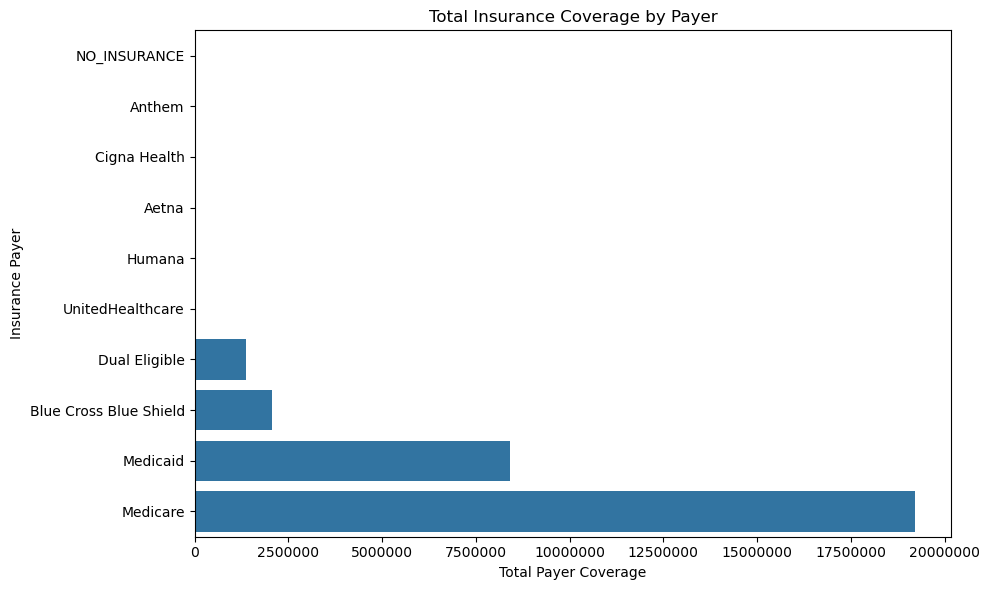

In [48]:
# Vizualization : Total Payer Coverage by Insurance Type
coverage_by_payer_sorted = coverage_by_payer.sort_values(
    "total_payer_coverage",
    ascending=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=coverage_by_payer_sorted,
    y="payer_name",
    x="total_payer_coverage"
)

plt.title("Total Insurance Coverage by Payer")
plt.xlabel("Total Payer Coverage")
plt.ylabel("Insurance Payer")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

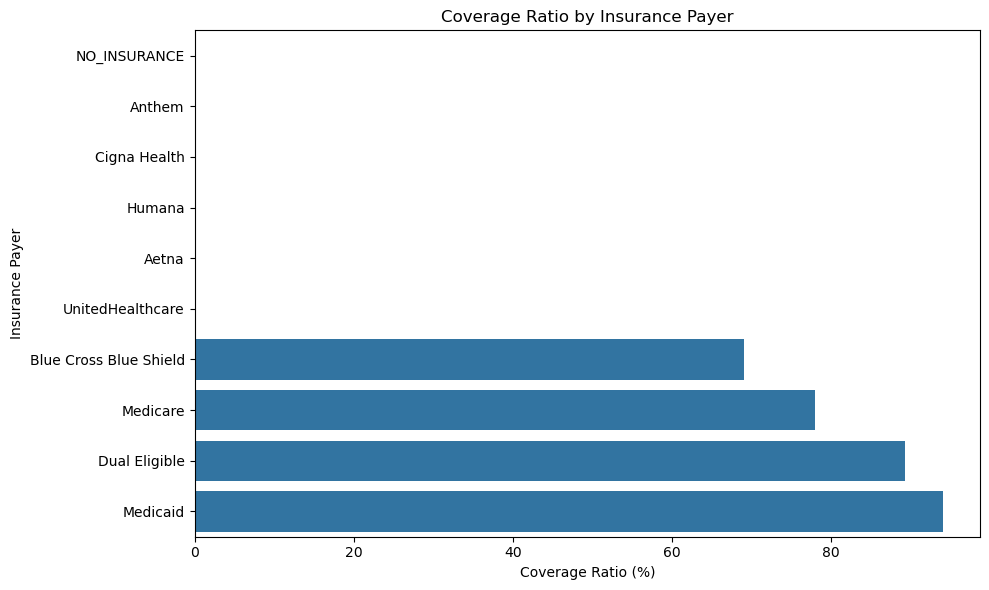

In [50]:
# Visualization: Coverage Ratio by Payer
coverage_ratio_sorted = coverage_by_payer.sort_values(
    "coverage_ratio_percent",
    ascending=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=coverage_ratio_sorted,
    y="payer_name",
    x="coverage_ratio_percent"
)

plt.title("Coverage Ratio by Insurance Payer")
plt.xlabel("Coverage Ratio (%)")
plt.ylabel("Insurance Payer")
plt.tight_layout()
plt.show()

### Business Question 6: Which insurance type covers the highest cost?

Medicare provides the highest total payer coverage, contributing 19.22 million in insurance payments. Medicaid is the second highest, contributing 8.42 million.

However, when coverage ratio is analyzed, Medicaid has the highest coverage percentage at 94.01%, followed by Dual Eligible at 89.25%, Medicare at 77.96%, and Blue Cross Blue Shield at 69.10%.

This shows that total payer contribution and coverage efficiency are different metrics. Medicare has the highest total financial contribution because it covers a large number of encounters, while Medicaid covers the highest percentage of claim cost.

The NO_INSURANCE category represents a major financial risk. It has 8,807 encounters, 49.26 million in total claim cost, and zero payer coverage. This means the entire cost is treated as patient responsibility.

For hospital finance teams, this insight is important because payer mix directly affects revenue recovery, patient affordability, and financial risk.

# Business Question 7
What are the most common procedures performed?

We will analyze procedure volume, patient coverage, and cost impact.

In [51]:
# Top Procedures by Count
top_procedures_by_count = procedures.groupby("DESCRIPTION").agg(
    total_procedures=("DESCRIPTION", "count"),
    unique_patients=("PATIENT", "nunique"),
    unique_encounters=("ENCOUNTER", "nunique"),
    avg_base_cost=("BASE_COST", "mean"),
    total_base_cost=("BASE_COST", "sum")
).reset_index()

top_procedures_by_count = top_procedures_by_count.sort_values(
    "total_procedures",
    ascending=False
)

top_procedures_by_count.head(15)

,DESCRIPTION,total_procedures,unique_patients,unique_encounters,avg_base_cost,total_base_cost
11,Assessment of health and social care needs (pr...,4596,509,4596,431.000000,1980876
69,Hospice care (regime/therapy),4098,61,162,431.000000,1766238
46,Depression screening using Patient Health Ques...,3614,500,3614,431.000000,1557634
44,Depression screening (procedure),3614,500,3614,431.000000,1557634
12,Assessment of substance use (procedure),2906,436,2906,431.000000,1252486
124,Renal dialysis (procedure),2746,5,2746,1004.086307,2757221
14,Assessment using Morse Fall Scale (procedure),2422,268,2422,431.000000,1043882
10,Assessment of anxiety (procedure),2288,437,2288,431.000000,986128
95,Medication Reconciliation (procedure),2284,418,2284,509.124343,1162840
132,Screening for drug abuse (procedure),1484,333,1484,431.000000,639604


In [52]:
# Top Procedures by Total Cost
top_procedures_by_cost = procedures.groupby("DESCRIPTION").agg(
    total_procedures=("DESCRIPTION", "count"),
    unique_patients=("PATIENT", "nunique"),
    unique_encounters=("ENCOUNTER", "nunique"),
    avg_base_cost=("BASE_COST", "mean"),
    total_base_cost=("BASE_COST", "sum")
).reset_index()

top_procedures_by_cost = top_procedures_by_cost.sort_values(
    "total_base_cost",
    ascending=False
)

top_procedures_by_cost.head(15)

,DESCRIPTION,total_procedures,unique_patients,unique_encounters,avg_base_cost,total_base_cost
50,Electrical cardioversion,1383,74,1383,25903.110629,35824002
17,Auscultation of the fetal heart,1065,71,1065,5312.508920,5657822
54,Evaluation of uterine fundal height,1065,71,1065,5287.587793,5631281
36,Combined chemotherapy and radiation therapy (p...,444,21,444,11796.387387,5237596
35,Colonoscopy,424,233,424,11841.988208,5021003
27,Catheter ablation of tissue of heart,365,54,365,9331.504110,3405999
124,Renal dialysis (procedure),2746,5,2746,1004.086307,2757221
11,Assessment of health and social care needs (pr...,4596,509,4596,431.000000,1980876
23,Bone density scan (procedure),198,115,198,9602.863636,1901367
69,Hospice care (regime/therapy),4098,61,162,431.000000,1766238


In [53]:
# Top Procedures by Average Cost
top_procedures_by_avg_cost = procedures.groupby("DESCRIPTION").agg(
    total_procedures=("DESCRIPTION", "count"),
    unique_patients=("PATIENT", "nunique"),
    unique_encounters=("ENCOUNTER", "nunique"),
    avg_base_cost=("BASE_COST", "mean"),
    total_base_cost=("BASE_COST", "sum")
).reset_index()

top_procedures_by_avg_cost = top_procedures_by_avg_cost.sort_values(
    "avg_base_cost",
    ascending=False
)

top_procedures_by_avg_cost.head(15)

,DESCRIPTION,total_procedures,unique_patients,unique_encounters,avg_base_cost,total_base_cost
4,Admit to ICU (procedure),5,2,2,206260.400000,1031302
39,Coronary artery bypass grafting,9,8,9,47085.888889,423773
86,Lumpectomy of breast (procedure),5,5,5,29353.000000,146765
64,Hemodialysis (procedure),27,4,4,29299.555556,791088
76,Insertion of biventricular implantable cardiov...,4,4,4,27201.000000,108804
50,Electrical cardioversion,1383,74,1383,25903.110629,35824002
103,Partial resection of colon,7,7,7,25229.285714,176605
60,Fine needle aspiration biopsy of lung (procedure),1,1,1,23141.000000,23141
107,Percutaneous mechanical thrombectomy of portal...,57,55,57,20228.035088,1152998
106,Percutaneous coronary intervention,9,8,9,19728.000000,177552


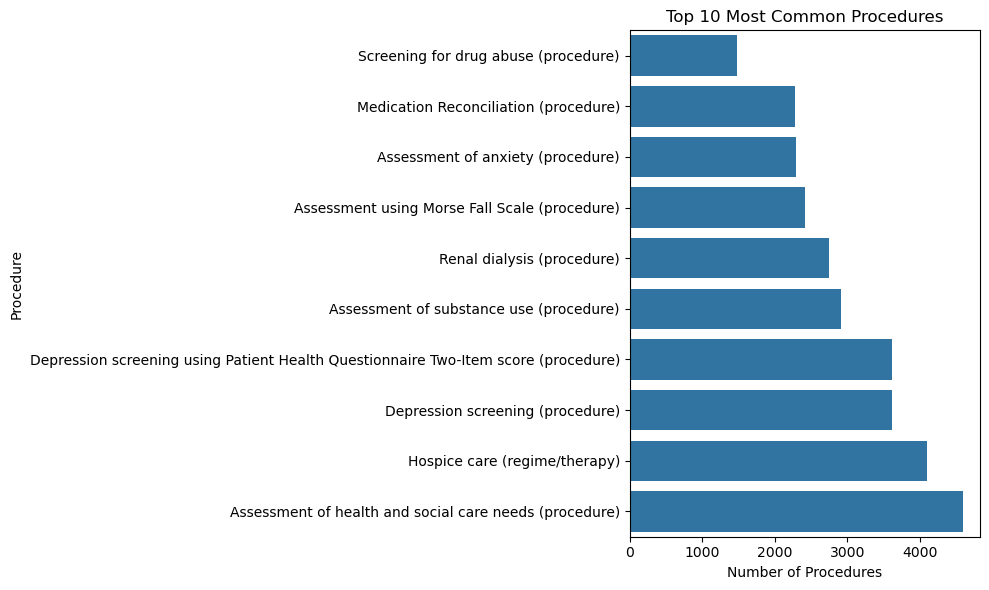

In [54]:
# Visualization: Top 10 Procedures by Count
top_10_procedures_count = top_procedures_by_count.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_procedures_count.sort_values("total_procedures", ascending=True),
    y="DESCRIPTION",
    x="total_procedures"
)

plt.title("Top 10 Most Common Procedures")
plt.xlabel("Number of Procedures")
plt.ylabel("Procedure")
plt.tight_layout()
plt.show()

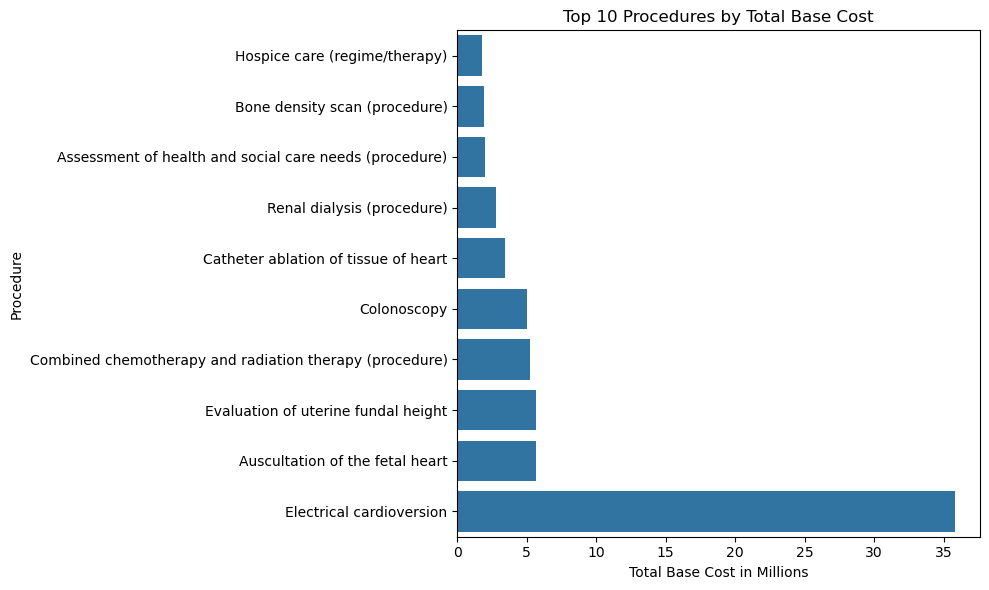

In [56]:
# Visualization: Top 10 Procedures by Total Cost
top_10_procedures_cost = top_procedures_by_cost.head(10).copy()

top_10_procedures_cost["total_base_cost_million"] = (
    top_10_procedures_cost["total_base_cost"] / 1_000_000
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_procedures_cost.sort_values("total_base_cost_million", ascending=True),
    y="DESCRIPTION",
    x="total_base_cost_million"
)

plt.title("Top 10 Procedures by Total Base Cost")
plt.xlabel("Total Base Cost in Millions")
plt.ylabel("Procedure")
plt.tight_layout()
plt.show()

### Business Question 7: What are the most common procedures performed?

The most common procedure is Assessment of health and social care needs, with 4,596 recorded procedures. Other high-volume procedures include hospice care, depression screening, Patient Health Questionnaire screening, assessment of substance use, renal dialysis, fall risk assessment, anxiety assessment, and medication reconciliation.

Most of the highest-volume procedures are screening, assessment, or care-management related. This suggests that a large part of hospital procedure workload comes from routine monitoring, mental health screening, social care assessment, and chronic care support.

However, cost analysis shows a different pattern. Electrical cardioversion generates the highest total base cost at 35.82 million, even though it is not the most common procedure. Admit to ICU has the highest average procedure cost, but it appears only 5 times.

This shows that procedure analysis should be viewed from three angles: volume, total cost, and average cost. A procedure may be common but low-cost, while another may be less frequent but financially significant.

For hospital management, high-volume procedures are important for operational planning, while high-cost procedures are important for financial monitoring and cost-control strategy.

# Business Question 8
Which time period has peak hospital load?

We already looked at monthly trend earlier, but now we will analyze this more professionally by:
Year
Month
Year-Month
Day of week

In [57]:
# Peak Load by Year
peak_load_by_year = encounters.groupby("encounter_year").agg(
    total_encounters=("Id", "count"),
    unique_patients=("PATIENT", "nunique"),
    avg_claim_cost=("TOTAL_CLAIM_COST", "mean"),
    total_claim_cost=("TOTAL_CLAIM_COST", "sum")
).reset_index()

peak_load_by_year = peak_load_by_year.sort_values(
    "total_encounters",
    ascending=False
)

peak_load_by_year

,encounter_year,total_encounters,unique_patients,avg_claim_cost,total_claim_cost
3,2014,3885,630,3091.804934,12011662.17
10,2021,3530,649,2599.782436,9177232.00
9,2020,2519,519,4086.573227,10294077.96
2,2013,2495,570,4050.209567,10105272.87
4,2015,2469,553,4100.709959,10124652.89
5,2016,2451,552,3421.746683,8386701.12
6,2017,2360,546,4066.480708,9596894.47
7,2018,2292,535,3816.238381,8746818.37
8,2019,2228,514,4001.498555,8915338.78
1,2012,2106,559,4301.193780,9058314.10


In [58]:
# Peak Load by Month Name
peak_load_by_month = encounters.groupby("encounter_month_name").agg(
    total_encounters=("Id", "count"),
    unique_patients=("PATIENT", "nunique"),
    avg_claim_cost=("TOTAL_CLAIM_COST", "mean"),
    total_claim_cost=("TOTAL_CLAIM_COST", "sum")
).reset_index()

In [59]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

peak_load_by_month["encounter_month_name"] = pd.Categorical(
    peak_load_by_month["encounter_month_name"],
    categories=month_order,
    ordered=True
)

peak_load_by_month = peak_load_by_month.sort_values("encounter_month_name")

peak_load_by_month

,encounter_month_name,total_encounters,unique_patients,avg_claim_cost,total_claim_cost
4,January,2217,508,3952.312016,8762275.74
3,February,3028,570,2978.695921,9019491.25
7,March,2688,620,3157.470681,8487281.19
0,April,2312,573,3476.372176,8037372.47
8,May,2374,530,3538.789634,8401086.59
6,June,2181,475,4001.862939,8728063.07
5,July,2182,476,3804.703588,8301863.23
1,August,2129,471,4164.493424,8866206.50
11,September,2113,462,3559.234524,7520662.55
10,October,2087,460,3904.283622,8148239.92


In [60]:
#Peak Load by Year Month
peak_load_by_year_month = encounters.groupby("encounter_year_month").agg(
    total_encounters=("Id", "count"),
    unique_patients=("PATIENT", "nunique"),
    avg_claim_cost=("TOTAL_CLAIM_COST", "mean"),
    total_claim_cost=("TOTAL_CLAIM_COST", "sum")
).reset_index()

peak_load_by_year_month = peak_load_by_year_month.sort_values(
    "total_encounters",
    ascending=False
)

peak_load_by_year_month.head(10)

,encounter_year_month,total_encounters,unique_patients,avg_claim_cost,total_claim_cost
37,2014-02,1179,269,2110.391781,2488151.91
38,2014-03,456,266,2451.169803,1117733.43
122,2021-03,452,297,1444.713872,653010.67
123,2021-04,421,284,1675.669525,705456.87
124,2021-05,342,206,2037.844825,696942.93
121,2021-02,328,226,1744.313750,572134.91
130,2021-11,267,134,3104.703296,828955.78
119,2020-12,267,139,3831.245281,1022942.49
120,2021-01,263,166,3828.589886,1006919.14
126,2021-07,263,154,3000.209049,789054.98


In [61]:
# Create Day of Week Column

encounters["day_of_week"] = encounters["START"].dt.day_name()

In [62]:
peak_load_by_day = encounters.groupby("day_of_week").agg(
    total_encounters=("Id", "count"),
    unique_patients=("PATIENT", "nunique"),
    avg_claim_cost=("TOTAL_CLAIM_COST", "mean"),
    total_claim_cost=("TOTAL_CLAIM_COST", "sum")
).reset_index()

In [63]:
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday", 
    "Friday", "Saturday", "Sunday"
]

peak_load_by_day["day_of_week"] = pd.Categorical(
    peak_load_by_day["day_of_week"],
    categories=day_order,
    ordered=True
)

peak_load_by_day = peak_load_by_day.sort_values("day_of_week")

peak_load_by_day

,day_of_week,total_encounters,unique_patients,avg_claim_cost,total_claim_cost
1,Monday,4405,603,4398.298751,19374506.00
5,Tuesday,3644,627,4405.322991,16052996.98
6,Wednesday,4370,602,4575.512586,19994990.00
4,Thursday,3477,607,3346.621231,11636202.02
0,Friday,4059,617,3433.821333,13937880.79
2,Saturday,3963,600,3154.292894,12500462.74
3,Sunday,3973,598,2017.955447,8017336.99


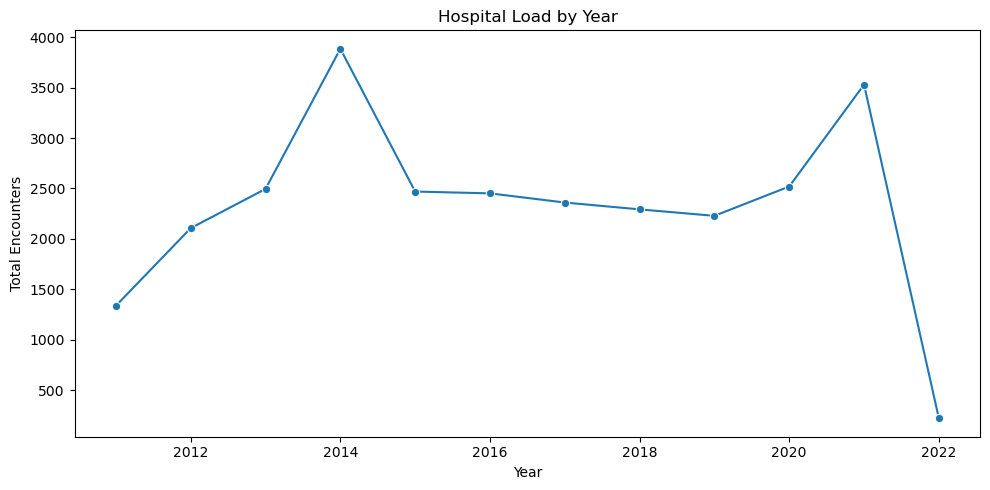

In [64]:
# Visualization Yearly Load Chart
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=peak_load_by_year.sort_values("encounter_year"),
    x="encounter_year",
    y="total_encounters",
    marker="o"
)

plt.title("Hospital Load by Year")
plt.xlabel("Year")
plt.ylabel("Total Encounters")
plt.tight_layout()
plt.show()

# 
Most Busiest year is 2014 with 
3,885 total encounters
630 unique patients
12.01 million total claim cost

Second busiest year is 2021 with
3,530 total encounters
649 unique patients
9.17 million total claim cost

Important note: 2022 should not be treated as a low-load year because the dataset only runs until early February 2022.

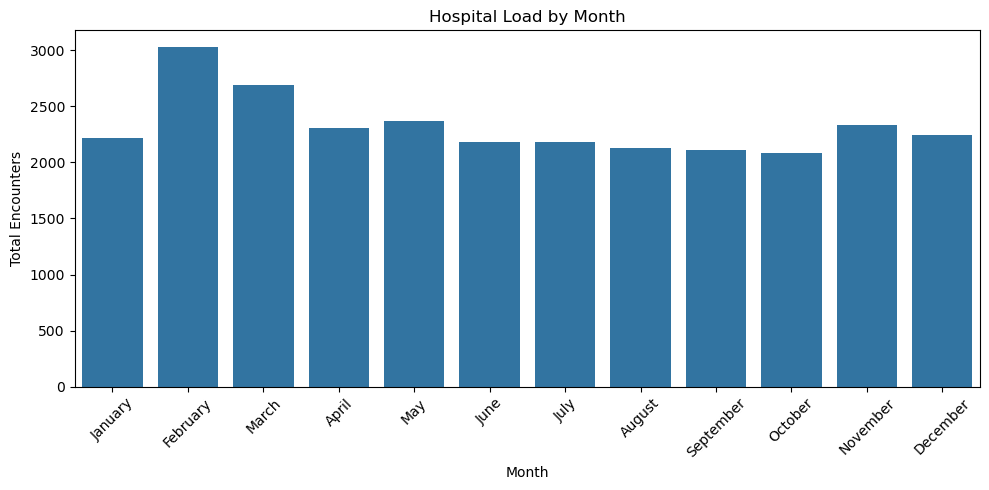

In [65]:
# Monthly Seasonality Chart

plt.figure(figsize=(10, 5))

sns.barplot(
    data=peak_load_by_month,
    x="encounter_month_name",
    y="total_encounters"
)

plt.title("Hospital Load by Month")
plt.xlabel("Month")
plt.ylabel("Total Encounters")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#
The busiest month overall is February
3,028 total encounters
570 unique patients
9.02 million total claim cost

March is the second busiest month having 2,688 total encounters

The busiest individual month is: February 2014 with 
1,179 total encounters
269 unique patients
24.88 lakh total claim cost

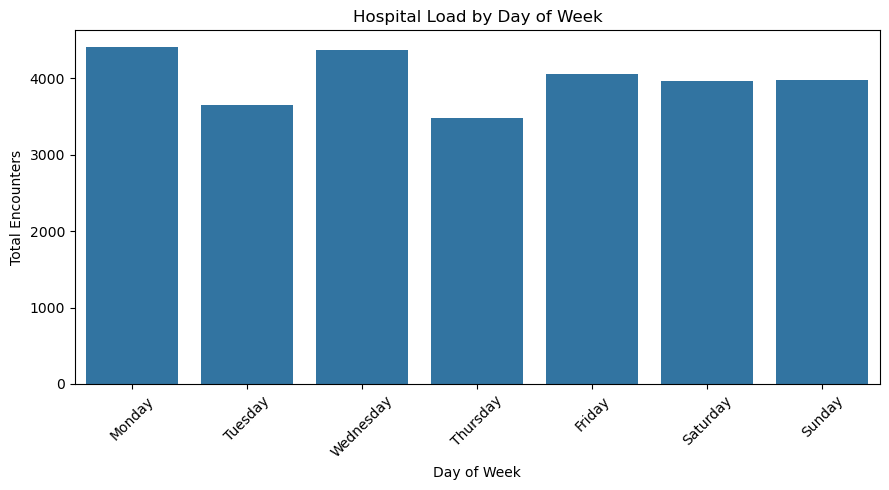

In [66]:
#Day of week chart
plt.figure(figsize=(9, 5))

sns.barplot(
    data=peak_load_by_day,
    x="day_of_week",
    y="total_encounters"
)

plt.title("Hospital Load by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Encounters")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 
The busiest day is: Monday with
4,405 total encounters
603 unique patients
19.37 million total claim cost

Wednesday is also very high: 3,477 encounters

The lowest weekday load is:Thursday with 3,477 encounters

 ### Business Question 8: Which time period has peak hospital load?

The hospital recorded its highest annual load in 2014, with 3,885 total encounters and 630 unique patients. The second highest load was observed in 2021, with 3,530 encounters and 649 unique patients.

At the monthly level, February shows the highest overall hospital load, followed by March. This indicates higher demand during the early part of the year.

At the year-month level, February 2014 was the busiest individual period, with 1,179 encounters and 269 unique patients. Several months from 2021 also appear among the busiest periods.

At the day-of-week level, Monday has the highest encounter volume, followed closely by Wednesday. This may indicate higher patient inflow at the start of the working week.

The decline in 2022 should not be interpreted as an actual drop in demand because the dataset ends in February 2022. Therefore, 2022 is an incomplete year and should be treated carefully in trend analysis.

For hospital operations, these insights can support staffing, appointment scheduling, capacity planning, and resource allocation during high-load periods.

# Business Question 9
What is the readmission rate by patient demographics?
For this we need encounters_sorted + patients

We already have readmission columns in encounters_sorted:
is_readmission
is_30_day_readmission
days_since_previous_visit

In [67]:
# Create Readmission Demographics Table
readmission_demo = encounters_sorted.merge(
    patients[["Id", "BIRTHDATE", "GENDER", "RACE", "ETHNICITY", "MARITAL"]],
    left_on="PATIENT",
    right_on="Id",
    how="left",
    suffixes=("", "_patient")
)

In [68]:
readmission_demo["age_at_encounter"] = (
    readmission_demo["START"].dt.year - readmission_demo["BIRTHDATE"].dt.year
)

In [69]:
def age_group(age):
    if pd.isna(age):
        return "Unknown"
    elif age <= 18:
        return "0-18"
    elif age <= 35:
        return "19-35"
    elif age <= 50:
        return "36-50"
    elif age <= 65:
        return "51-65"
    else:
        return "65+"

readmission_demo["age_group"] = readmission_demo["age_at_encounter"].apply(age_group)

In [70]:
readmission_demo[[
    "PATIENT",
    "START",
    "age_group",
    "GENDER",
    "RACE",
    "ETHNICITY",
    "is_readmission",
    "is_30_day_readmission"
]].head()

,PATIENT,START,age_group,GENDER,RACE,ETHNICITY,is_readmission,is_30_day_readmission
0,002bc307-2fff-04ba-161b-98cce123e226,2011-12-22 19:30:33+00:00,65+,F,white,nonhispanic,First Admission,No
1,002bc307-2fff-04ba-161b-98cce123e226,2012-01-19 19:30:33+00:00,65+,F,white,nonhispanic,Readmission,Yes
2,002bc307-2fff-04ba-161b-98cce123e226,2014-06-19 19:30:33+00:00,65+,F,white,nonhispanic,Readmission,No
3,002bc307-2fff-04ba-161b-98cce123e226,2014-10-30 19:30:33+00:00,65+,F,white,nonhispanic,Readmission,No
4,002bc307-2fff-04ba-161b-98cce123e226,2014-11-29 19:30:33+00:00,65+,F,white,nonhispanic,Readmission,Yes


In [71]:
# Readmission Rate by Age Group

readmission_by_age = readmission_demo.groupby("age_group").agg(
    total_encounters=("Id", "count"),
    unique_patients=("PATIENT", "nunique"),
    readmissions=("is_readmission", lambda x: (x == "Readmission").sum()),
    thirty_day_readmissions=("is_30_day_readmission", lambda x: (x == "Yes").sum())
).reset_index()

readmission_by_age["readmission_rate"] = (
    readmission_by_age["readmissions"] / readmission_by_age["total_encounters"] * 100
).round(2)

readmission_by_age["thirty_day_readmission_rate"] = (
    readmission_by_age["thirty_day_readmissions"] / readmission_by_age["total_encounters"] * 100
).round(2)

readmission_by_age = readmission_by_age.sort_values(
    "thirty_day_readmission_rate",
    ascending=False
)

readmission_by_age

,age_group,total_encounters,unique_patients,readmissions,thirty_day_readmissions,readmission_rate,thirty_day_readmission_rate
3,65+,18626,548,18166,11818,97.53,63.45
0,19-35,2441,141,2300,1400,94.22,57.35
2,51-65,3616,268,3432,1647,94.91,45.55
1,36-50,3208,263,3019,1369,94.11,42.67


In [72]:
# Readmission Rate by Gender
readmission_by_gender = readmission_demo.groupby("GENDER").agg(
    total_encounters=("Id", "count"),
    unique_patients=("PATIENT", "nunique"),
    readmissions=("is_readmission", lambda x: (x == "Readmission").sum()),
    thirty_day_readmissions=("is_30_day_readmission", lambda x: (x == "Yes").sum())
).reset_index()

readmission_by_gender["readmission_rate"] = (
    readmission_by_gender["readmissions"] / readmission_by_gender["total_encounters"] * 100
).round(2)

readmission_by_gender["thirty_day_readmission_rate"] = (
    readmission_by_gender["thirty_day_readmissions"] / readmission_by_gender["total_encounters"] * 100
).round(2)

readmission_by_gender

,GENDER,total_encounters,unique_patients,readmissions,thirty_day_readmissions,readmission_rate,thirty_day_readmission_rate
0,F,14924,480,14444,8339,96.78,55.88
1,M,12967,494,12473,7895,96.19,60.89


# Male patients show a moderately higher 30-day repeat encounter rate compared to female patients in this dataset.

In [73]:
# Readmission Rate by Race

readmission_by_race = readmission_demo.groupby("RACE").agg(
    total_encounters=("Id", "count"),
    unique_patients=("PATIENT", "nunique"),
    readmissions=("is_readmission", lambda x: (x == "Readmission").sum()),
    thirty_day_readmissions=("is_30_day_readmission", lambda x: (x == "Yes").sum())
).reset_index()

readmission_by_race["readmission_rate"] = (
    readmission_by_race["readmissions"] / readmission_by_race["total_encounters"] * 100
).round(2)

readmission_by_race["thirty_day_readmission_rate"] = (
    readmission_by_race["thirty_day_readmissions"] / readmission_by_race["total_encounters"] * 100
).round(2)

readmission_by_race = readmission_by_race.sort_values(
    "thirty_day_readmission_rate",
    ascending=False
)

readmission_by_race

,RACE,total_encounters,unique_patients,readmissions,thirty_day_readmissions,readmission_rate,thirty_day_readmission_rate
3,native,859,11,848,724,98.72,84.28
0,asian,2519,91,2428,1590,96.39,63.12
1,black,4403,163,4240,2615,96.30,59.39
5,white,19460,680,18780,11005,96.51,56.55
2,hawaiian,371,13,358,198,96.50,53.37
4,other,279,16,263,102,94.27,36.56


In [74]:
# Readmission Rate by Ethnicity
readmission_by_ethnicity = readmission_demo.groupby("ETHNICITY").agg(
    total_encounters=("Id", "count"),
    unique_patients=("PATIENT", "nunique"),
    readmissions=("is_readmission", lambda x: (x == "Readmission").sum()),
    thirty_day_readmissions=("is_30_day_readmission", lambda x: (x == "Yes").sum())
).reset_index()

readmission_by_ethnicity["readmission_rate"] = (
    readmission_by_ethnicity["readmissions"] / readmission_by_ethnicity["total_encounters"] * 100
).round(2)

readmission_by_ethnicity["thirty_day_readmission_rate"] = (
    readmission_by_ethnicity["thirty_day_readmissions"] / readmission_by_ethnicity["total_encounters"] * 100
).round(2)

readmission_by_ethnicity

,ETHNICITY,total_encounters,unique_patients,readmissions,thirty_day_readmissions,readmission_rate,thirty_day_readmission_rate
0,hispanic,4630,191,4439,2487,95.87,53.71
1,nonhispanic,23261,783,22478,13747,96.63,59.10


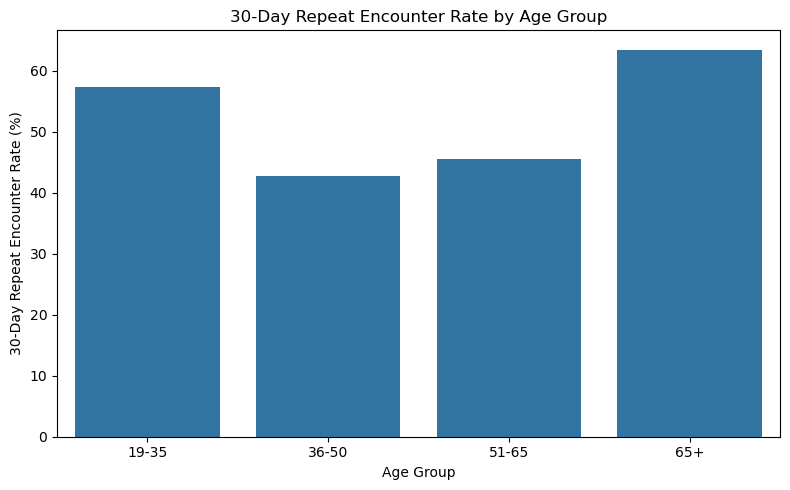

In [78]:
# Visualization
# Readmission Rate by Age Group
age_order_existing = ["19-35", "36-50", "51-65", "65+"]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=readmission_by_age,
    x="age_group",
    y="thirty_day_readmission_rate",
    order=age_order_existing
)

plt.title("30-Day Repeat Encounter Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("30-Day Repeat Encounter Rate (%)")
plt.tight_layout()
plt.show()

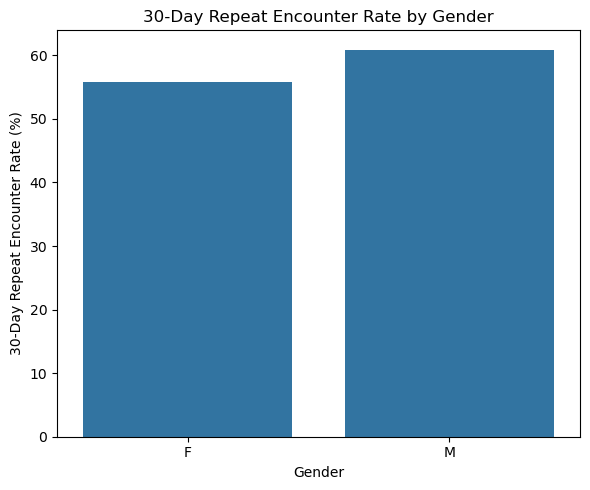

In [76]:
# Readmission Rate by Gender
plt.figure(figsize=(6, 5))

sns.barplot(
    data=readmission_by_gender,
    x="GENDER",
    y="thirty_day_readmission_rate"
)

plt.title("30-Day Repeat Encounter Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("30-Day Repeat Encounter Rate (%)")
plt.tight_layout()
plt.show()

#Readmission rate by race
plt.figure(figsize=(8, 5))

sns.barplot(
    data=readmission_by_race,
    x="RACE",
    y="thirty_day_readmission_rate"
)

plt.title("30-Day Repeat Encounter Rate by Race")
plt.xlabel("Race")
plt.ylabel("30-Day Repeat Encounter Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation Note

In this project, 30-day repeat encounter rate is used as a proxy for readmission behaviour. Since the dataset includes inpatient, outpatient, ambulatory, emergency, urgent care, and wellness encounters, this metric should not be interpreted as strict clinical readmission.

### Business Question 9: What is the readmission rate by patient demographics?

The 65+ age group has the highest 30-day repeat encounter rate at 63.45%. This group also has the highest number of total encounters and unique patients, indicating that elderly patients create both high hospital volume and high repeat-visit pressure.

The 19-35 age group has the second-highest 30-day repeat encounter rate at 57.35%, even though their total encounter volume is much lower than the 65+ group. This may indicate that younger adult encounters are fewer but more concentrated among repeat visitors.

By gender, male patients show a moderately higher 30-day repeat encounter rate at 60.89%, compared to 55.88% among female patients.

By race, the native group shows the highest 30-day repeat encounter rate at 84.28%. However, this should be interpreted carefully because the group has only 11 unique patients, making the rate less stable. Among larger groups, Asian, Black, and White patients show rates between 56% and 63%.

By ethnicity, non-Hispanic patients show a higher 30-day repeat encounter rate at 59.10%, compared to 53.71% among Hispanic patients.

For hospital management, demographic-level repeat encounter analysis can support targeted care management, follow-up planning, and chronic care monitoring. However, small demographic groups should be interpreted cautiously to avoid misleading conclusions.

# Business Question 10
Which procedures or departments generate the highest revenue?

# We will use
TOTAL_CLAIM_COST as encounter-level revenue proxy
BASE_COST as procedure-level revenue proxy

In [80]:
#Highest revenue procedures
procedure_revenue = procedures.groupby("DESCRIPTION").agg(
    total_procedures=("DESCRIPTION", "count"),
    unique_patients=("PATIENT", "nunique"),
    unique_encounters=("ENCOUNTER", "nunique"),
    total_procedure_revenue_proxy=("BASE_COST", "sum"),
    avg_procedure_revenue_proxy=("BASE_COST", "mean")
).reset_index()

procedure_revenue = procedure_revenue.sort_values(
    "total_procedure_revenue_proxy",
    ascending=False
)

procedure_revenue.head(15)

,DESCRIPTION,total_procedures,unique_patients,unique_encounters,total_procedure_revenue_proxy,avg_procedure_revenue_proxy
50,Electrical cardioversion,1383,74,1383,35824002,25903.110629
17,Auscultation of the fetal heart,1065,71,1065,5657822,5312.508920
54,Evaluation of uterine fundal height,1065,71,1065,5631281,5287.587793
36,Combined chemotherapy and radiation therapy (p...,444,21,444,5237596,11796.387387
35,Colonoscopy,424,233,424,5021003,11841.988208
27,Catheter ablation of tissue of heart,365,54,365,3405999,9331.504110
124,Renal dialysis (procedure),2746,5,2746,2757221,1004.086307
11,Assessment of health and social care needs (pr...,4596,509,4596,1980876,431.000000
23,Bone density scan (procedure),198,115,198,1901367,9602.863636
69,Hospice care (regime/therapy),4098,61,162,1766238,431.000000


# The highest procedure-level revenue proxy comes from: Electrical cardioversion. It generated 35.82 million from 1,383 procedures 74 unique patients

In [81]:
# Highest Revenue Encounter Classes
encounter_class_revenue = encounters.groupby("ENCOUNTERCLASS").agg(
    total_encounters=("Id", "count"),
    unique_patients=("PATIENT", "nunique"),
    total_revenue_proxy=("TOTAL_CLAIM_COST", "sum"),
    avg_revenue_proxy=("TOTAL_CLAIM_COST", "mean"),
    total_payer_coverage=("PAYER_COVERAGE", "sum"),
    total_patient_cost=("patient_out_of_pocket_cost", "sum")
).reset_index()

encounter_class_revenue = encounter_class_revenue.sort_values(
    "total_revenue_proxy",
    ascending=False
)

encounter_class_revenue

,ENCOUNTERCLASS,total_encounters,unique_patients,total_revenue_proxy,avg_revenue_proxy,total_payer_coverage,total_patient_cost
0,ambulatory,12537,695,36283440.84,2894.108705,12903495.75,23379945.09
4,urgentcare,3666,247,23349349.96,6369.162564,3058909.73,20290440.23
3,outpatient,6300,624,14094967.12,2237.296368,3777758.35,10317208.77
1,emergency,2322,465,10750051.53,4629.651822,3246828.27,7503223.26
2,inpatient,1135,153,8809134.34,7761.351841,3688764.95,5120369.39
5,wellness,1931,209,8227431.73,4260.710373,4421749.94,3805681.79


# The highest encounter-level revenue proxy comes from: Ambulatory. It generated 36.28 million from 12,537 encounters 695 unique patients

In [82]:
# Revenue by Payer and Encounter Class
payer_encounter_revenue = encounters_payer.groupby(
    ["payer_name", "ENCOUNTERCLASS"]
).agg(
    total_encounters=("Id", "count"),
    total_claim_cost=("TOTAL_CLAIM_COST", "sum"),
    total_payer_coverage=("PAYER_COVERAGE", "sum"),
    total_patient_cost=("patient_out_of_pocket_cost", "sum")
).reset_index()

payer_encounter_revenue = payer_encounter_revenue.sort_values(
    "total_claim_cost",
    ascending=False
)

payer_encounter_revenue.head(20)

,payer_name,ENCOUNTERCLASS,total_encounters,total_claim_cost,total_payer_coverage,total_patient_cost
52,NO_INSURANCE,urgentcare,1499,19414909.39,0.00,19414909.39
48,NO_INSURANCE,ambulatory,4453,12582242.11,0.00,12582242.11
36,Medicaid,ambulatory,768,7452005.63,7034158.78,417846.85
51,NO_INSURANCE,outpatient,1631,6779241.08,0.00,6779241.08
49,NO_INSURANCE,emergency,555,5428222.01,0.00,5428222.01
42,Medicare,ambulatory,4432,5187016.53,3981092.40,1205924.13
47,Medicare,wellness,986,5107193.15,4044067.74,1063125.41
46,Medicare,urgentcare,1796,3808344.98,2988872.67,819472.31
44,Medicare,inpatient,495,3802757.63,3016347.96,786409.67
45,Medicare,outpatient,2251,3601667.19,2723800.49,877866.70


# The highest payer-encounter financial impact is: NO_INSURANCE + urgentcare with 19.41 million total claim cost 0 payer coverage 19.41 million patient cost

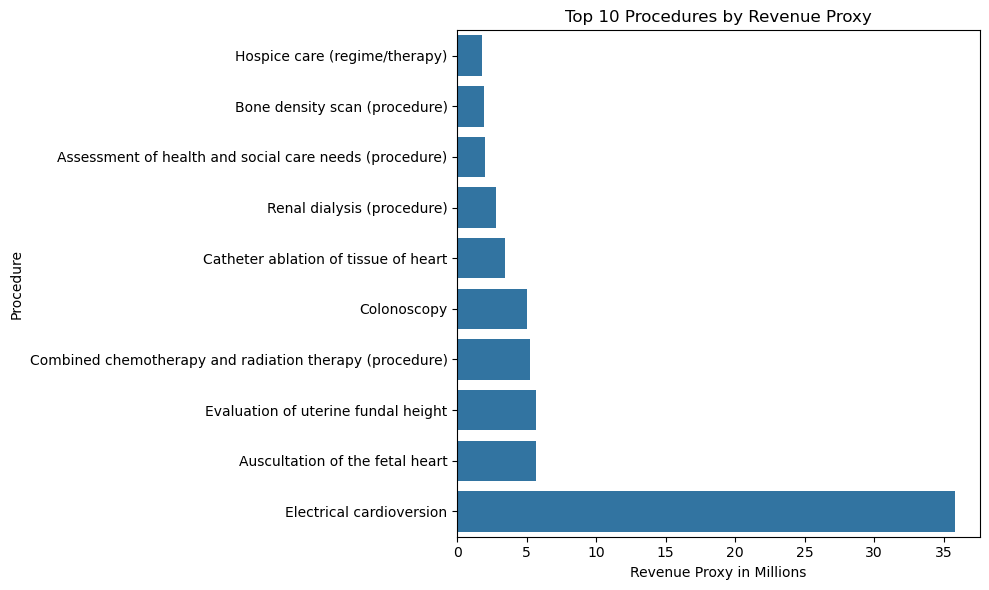

In [83]:
# Visualization: Top 10 Revenue Procedures
top_10_revenue_procedures = procedure_revenue.head(10).copy()

top_10_revenue_procedures["revenue_proxy_million"] = (
    top_10_revenue_procedures["total_procedure_revenue_proxy"] / 1_000_000
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_revenue_procedures.sort_values("revenue_proxy_million", ascending=True),
    y="DESCRIPTION",
    x="revenue_proxy_million"
)

plt.title("Top 10 Procedures by Revenue Proxy")
plt.xlabel("Revenue Proxy in Millions")
plt.ylabel("Procedure")
plt.tight_layout()
plt.show()

# Electrical cardioversion dominates procedure-level revenue proxy.

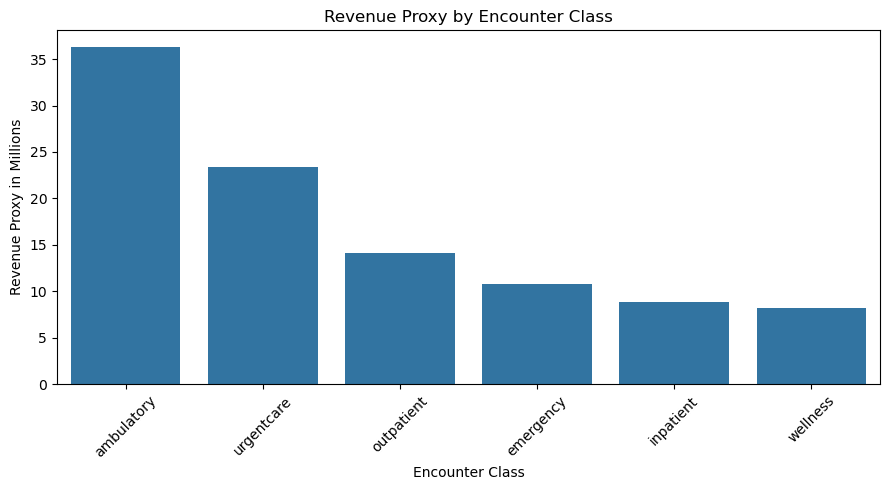

In [84]:
#Visualization: Revenue by Encounter Class
encounter_class_revenue_chart = encounter_class_revenue.copy()

encounter_class_revenue_chart["revenue_proxy_million"] = (
    encounter_class_revenue_chart["total_revenue_proxy"] / 1_000_000
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=encounter_class_revenue_chart.sort_values("revenue_proxy_million", ascending=False),
    x="ENCOUNTERCLASS",
    y="revenue_proxy_million"
)

plt.title("Revenue Proxy by Encounter Class")
plt.xlabel("Encounter Class")
plt.ylabel("Revenue Proxy in Millions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Ambulatory encounters dominate encounter-level revenue proxy.

### Revenue Proxy Note

The dataset does not contain actual hospital revenue or department-level income. Therefore, TOTAL_CLAIM_COST is used as an encounter-level revenue proxy, and BASE_COST is used as a procedure-level revenue proxy. These values should be interpreted as financial impact rather than confirmed realized revenue.

### Business Question 10: Which procedures or departments generate the highest revenue?

The dataset does not contain confirmed hospital revenue or department-level income. Therefore, TOTAL_CLAIM_COST is used as an encounter-level revenue proxy, and BASE_COST is used as a procedure-level revenue proxy. These values should be interpreted as financial impact rather than confirmed realized revenue.

At the procedure level, Electrical cardioversion generates the highest revenue proxy, with 35.82 million across 1,383 procedures and 74 unique patients. This makes it the strongest procedure-level financial driver in the dataset.

Other important high-revenue procedures include Auscultation of the fetal heart, Evaluation of uterine fundal height, Combined chemotherapy and radiation therapy, Colonoscopy, Catheter ablation of tissue of heart, and Renal dialysis.

At the encounter-class level, ambulatory encounters generate the highest total revenue proxy at 36.28 million, followed by urgent care and outpatient encounters. This shows that high-volume services can create larger total financial impact even when their average cost per encounter is lower.

Earlier analysis showed that inpatient encounters have the highest average cost per visit. However, ambulatory encounters generate the highest total financial impact because of their much higher volume.

The payer-encounter analysis shows that NO_INSURANCE combined with urgent care, ambulatory, outpatient, and emergency encounters creates a major financial burden. These categories have high total claim costs but zero payer coverage, meaning the full cost is assigned to patient responsibility.

For hospital management, this insight is important because revenue planning should monitor both high-cost procedures and high-volume encounter classes. Finance teams should also pay close attention to uninsured high-cost encounter categories because they may increase patient affordability risk and collection challenges.

In [88]:
final_encounters = encounters.copy()
final_patients = patients.copy()
final_procedures = procedures.copy()
final_payers = payers.copy()
final_organizations = organizations.copy()

final_encounters_readmission = encounters_sorted.copy()
final_encounters_patient = encounters_patient.copy()
final_procedures_coverage = procedures_with_coverage.copy()
final_encounters_payer = encounters_payer.copy()

In [89]:
final_patients.to_csv("Data/final_patients.csv", index=False)
final_encounters.to_csv("Data/final_encounters.csv", index=False)
final_procedures.to_csv("Data/final_procedures.csv", index=False)
final_payers.to_csv("Data/final_payers.csv", index=False)
final_organizations.to_csv("Data/final_organizations.csv", index=False)

final_encounters_readmission.to_csv("Data/final_encounters_readmission.csv", index=False)
final_encounters_patient.to_csv("Data/final_encounters_patient.csv", index=False)
final_procedures_coverage.to_csv("Data/final_procedures_coverage.csv", index=False)
final_encounters_payer.to_csv("Data/final_encounters_payer.csv", index=False)

In [90]:
admission_trend.to_csv("Data/summary_admission_trend.csv", index=False)
los_by_encounter_class.to_csv("Data/summary_los_by_encounter_class.csv", index=False)
cost_by_encounter_class.to_csv("Data/summary_cost_by_encounter_class.csv", index=False)
procedure_coverage_summary.to_csv("Data/summary_procedure_coverage.csv", index=False)
admissions_by_age_group.to_csv("Data/summary_admissions_by_age_group.csv", index=False)
coverage_by_payer.to_csv("Data/summary_coverage_by_payer.csv", index=False)
top_procedures_by_count.to_csv("Data/summary_top_procedures_by_count.csv", index=False)
peak_load_by_year.to_csv("Data/summary_peak_load_by_year.csv", index=False)
readmission_by_age.to_csv("Data/summary_readmission_by_age.csv", index=False)
procedure_revenue.to_csv("Data/summary_procedure_revenue.csv", index=False)
encounter_class_revenue.to_csv("Data/summary_encounter_class_revenue.csv", index=False)

In [91]:
import os

[file for file in os.listdir("Data") if file.startswith("final_") or file.startswith("summary_")]

['final_encounters.csv',
 'final_encounters_patient.csv',
 'final_encounters_payer.csv',
 'final_encounters_readmission.csv',
 'final_organizations.csv',
 'final_patients.csv',
 'final_payers.csv',
 'final_procedures.csv',
 'final_procedures_coverage.csv',
 'summary_admissions_by_age_group.csv',
 'summary_admission_trend.csv',
 'summary_cost_by_encounter_class.csv',
 'summary_coverage_by_payer.csv',
 'summary_encounter_class_revenue.csv',
 'summary_los_by_encounter_class.csv',
 'summary_peak_load_by_year.csv',
 'summary_procedure_coverage.csv',
 'summary_procedure_revenue.csv',
 'summary_readmission_by_age.csv',
 'summary_top_procedures_by_count.csv']

## Python Phase Summary

The Python phase included data loading, data cleaning, feature engineering, and exploratory data analysis.

Key cleaning steps included converting date columns, handling missing values, creating length of stay metrics, creating year-month fields, calculating patient age at encounter, creating age groups, identifying insurance coverage status, and deriving repeat encounter/readmission indicators.

The EDA answered 10 healthcare business questions related to admissions, readmissions, length of stay, cost per visit, insurance coverage, age-group utilization, payer coverage, procedure trends, peak hospital load, demographic readmission behaviour, and revenue proxy analysis.

Key insights include:

1. Hospital encounters peaked in 2014 and again in 2021.
2. February 2014 was the busiest month in the dataset.
3. Inpatient encounters have the highest average length of stay.
4. Inpatient encounters are most expensive per visit, but ambulatory encounters create the highest total financial impact.
5. Around 52% of procedures are covered by insurance, while 48% are not covered.
6. The 65+ age group has the highest hospital utilization and repeat-visit pressure.
7. Medicare has the highest total payer coverage, while Medicaid has the highest coverage ratio.
8. Health and social care assessment is the most common procedure.
9. Electrical cardioversion generates the highest procedure-level revenue proxy.
10. Uninsured encounters create a major patient financial burden.

The cleaned analytical datasets have been exported and are ready for SQL import and transformation.